## Objetivo do projeto

Este notebook implementa um pipeline de análise de sentimento de resenhas
utilizando um modelo de linguagem (LLM) via API (Groq).

## Etapas do projeto

1. Carregamento de um arquivo `.txt` contendo resenhas de usuários
2. Envio das resenhas ao modelo de linguagem para extração estruturada em JSON
3. Conversão da resposta do modelo em estruturas Python
4. Análise das avaliações (positivas, negativas e neutras)
5. Consolidação dos resultados para análise posterior

In [2]:
# Etapa 1: Leitura das resenhas

with open("Resenhas_App_ChatGPT.txt", "r", encoding="utf-8") as file:
    raw_reviews = [line.strip() for line in file]

# Exibição das primeiras 5 resenhas
raw_reviews[:5]

["53409593$Safoan Riyad$J'aimais bien ChatGPT. Mais la derniÃ¨re mise Ã  jour a tout gÃ¢chÃ©. Elle a tout oubliÃ©.",
 '39485494$Habimana Therese$This app is very important but sometimes it gives lies',
 '4549594$Shahidatun jannat$Wonderful app..i just aastonished.. love this app..',
 '890535$Rayyan R$Anytime i try to get the app to work. It tells me "an error has occured" can this be fixed',
 '3590353$Nkanyi Cele$Acabo de instalar la aplicaciÃ³n desde Google Play Store, pero lamentablemente no se abre. Se queda dando vueltas.']

Observação: após inspecionar as primeiras linhas, percebeu-se que os dados estão organizados da seguinte forma:

`IdUsuario$NomeUsuario$Resenha`

In [3]:
# Etapa 2: Configuração da API Groq
# Nesta etapa, carregamos a chave da API armazenada em `.env` e inicializamos o cliente Groq.

import os
from dotenv import load_dotenv
from groq import Groq

# Carregar variáveis de ambiente
load_dotenv()

# Obter chave da API
groq_key = os.getenv("GROQ_API_KEY")
if groq_key is None:
    print("❌ ERRO: A chave da API não foi encontrada. Verifique seu arquivo .env.")
    exit(1)  # Encerra o programa se a chave não estiver presente

# Inicializar cliente Groq
client = Groq()

Antes de enviar as resenhas, realizamos um teste simples para garantir que a conexão com o modelo está funcionando corretamente.

In [4]:
# Testando a conexão com o LLM

test_response = client.chat.completions.create(
    model="openai/gpt-oss-20b",
    messages=[
        {"role": "user", 
         "content": "O que é IA Generativa? Responda em 1 linha."}
    ]
)

print(test_response.choices[0].message.content)

IA Generativa é uma tecnologia que cria conteúdo original—texto, imagem, áudio ou vídeo—aprendendo padrões a partir de grandes volumes de dados.


Agora podemos enviar lista de resenhas ao modelo LLM para estruturar os dados em JSON.  
Cada item do JSON conterá:

- `usuario`: ID do usuário  
- `resenha_original`: texto da resenha original  
- `resenha_pt`: tradução da resenha para português  
- `avaliacao`: classificação da resenha em uma palavra: Positiva, Negativa ou Neutra

In [5]:
# Enviando a lista de resenhas ao modelo para extração em JSON

review_dict_str = client.chat.completions.create(
    model="openai/gpt-oss-20b",
    messages=[
        {
            "role": "user",
            "content": f"""Você é um analista de dados. Vou te passar uma lista em python, onde cada item é
             uma resenha do App ChatGPT, cada item da lista está organizado da seguinte forma: IdUsuario$NomeUsuario$Resenha. 
             Quero que você me retorne APENAS um texto no formato JSON, contento quatro chaves:
                - 'usuario': com a ID do usuario IdUsuario;
                - 'resenha_original': com o texto da resenha no idioma original; 
                - 'resenha_pt: com a tradução da resenha para pt-br;
                - 'avaliacao': Aqui você deve avaliar a resenha e retornar uma classificação em apenas uma palavra: Positiva,
                Negativa ou Neutra.
            
            Exemplo:
            o item na lista estava assim: '1234567$Renata Leite$The ChatGPT app stopped working after a week...'
            {{
                "usuario": "1234567",
                "resenha_original": "The ChatGPT app stopped working after a week.",
                "resenha_pt": "O app ChatGPT parou de funcionar após uma semana.",
                "avaliacao": "Negativa"
            }}

            retorne APENAS o texto no formato JSON, sem nada mais.

            Faça isso para todas as resenhas que vou te enviar na lista em python abaixo:
            {raw_reviews}
            """
        }
    ]
).choices[0].message.content

# Guardar a resposta JSON retornada pelo modelo
reviews_json = review_dict_str

# Exibir uma prévia
print(reviews_json[:500])  # mostra só os primeiros 500 caracteres

[
  {
    "usuario": "53409593",
    "resenha_original": "J'aimais bien ChatGPT. Mais la dernière mise à jour a tout gâché. Elle a tout oublié.",
    "resenha_pt": "Eu gostava do ChatGPT. Mas a última atualização estragou tudo. Ela esqueceu tudo.",
    "avaliacao": "Negativa"
  },
  {
    "usuario": "39485494",
    "resenha_original": "This app is very important but sometimes it gives lies",
    "resenha_pt": "Este aplicativo é muito importante, mas às vezes ele dá mentiras.",
    "avaliacao": "


In [9]:
# Etapa 3: Converter o JSON retornado pelo LLM em uma lista de dicionários Python

import json

reviews_with_sentiment = json.loads(reviews_json)

# Visualizar os 3 primeiros itens
reviews_with_sentiment[:3]

[{'usuario': '53409593',
  'resenha_original': "J'aimais bien ChatGPT. Mais la dernière mise à jour a tout gâché. Elle a tout oublié.",
  'resenha_pt': 'Eu gostava do ChatGPT. Mas a última atualização estragou tudo. Ela esqueceu tudo.',
  'avaliacao': 'Negativa'},
 {'usuario': '39485494',
  'resenha_original': 'This app is very important but sometimes it gives lies',
  'resenha_pt': 'Este aplicativo é muito importante, mas às vezes ele dá mentiras.',
  'avaliacao': 'Negativa'},
 {'usuario': '4549594',
  'resenha_original': 'Wonderful app..i just aastonished.. love this app..',
  'resenha_pt': 'Aplicativo maravilhoso.. estou maravilhado.. amo este app..',
  'avaliacao': 'Positiva'}]

In [10]:
# Verificando a quantidade de resenhas processadas
print(f"Total de resenhas processadas: {len(reviews_with_sentiment)}")

Total de resenhas processadas: 24


In [11]:
# Etapa 4: Função para contar avaliações e unir resenhas

# Esta função recebe a lista de dicionários de resenhas e realiza duas tarefas:
# 1. Conta quantas avaliações são Positiva, Negativa ou Neutra  
# 2. Une todos os dicionários em uma única string, separando cada item com "#####"

def count_and_combine_reviews(review_list):
    # Inicializar contadores
    positive_count = 0
    negative_count = 0
    neutral_count = 0

    # Lista para unir os dicionários
    combined_items = []

    for review in review_list:
        if review['avaliacao'] == 'Positiva':
            positive_count += 1
        elif review['avaliacao'] == 'Negativa':
            negative_count += 1
        else:
            neutral_count += 1
        
    # Adicionar dicionário à lista de itens unidos
        combined_items.append(str(review))

    # Unir todos os itens em uma única string com separador
    combined_string = '#####'.join(combined_items)
    
    return combined_string, positive_count, negative_count, neutral_count

In [12]:
# Aplicar a função
combined_reviews, pos_count, neg_count, neu_count = count_and_combine_reviews(reviews_with_sentiment)

# Exibir resultados
print(f"Avaliações: Positiva={pos_count}, Negativa={neg_count}, Neutra={neu_count}")
print("\nPrévia da string combinada:")
print(combined_reviews[:500])  # mostra apenas os primeiros 500 caracteres

Avaliações: Positiva=6, Negativa=15, Neutra=3

Prévia da string combinada:
{'usuario': '53409593', 'resenha_original': "J'aimais bien ChatGPT. Mais la dernière mise à jour a tout gâché. Elle a tout oublié.", 'resenha_pt': 'Eu gostava do ChatGPT. Mas a última atualização estragou tudo. Ela esqueceu tudo.', 'avaliacao': 'Negativa'}#####{'usuario': '39485494', 'resenha_original': 'This app is very important but sometimes it gives lies', 'resenha_pt': 'Este aplicativo é muito importante, mas às vezes ele dá mentiras.', 'avaliacao': 'Negativa'}#####{'usuario': '4549594', 'r


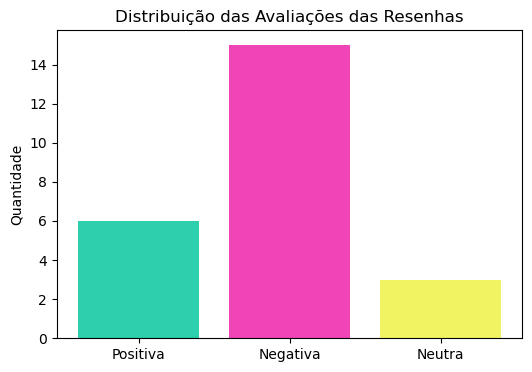

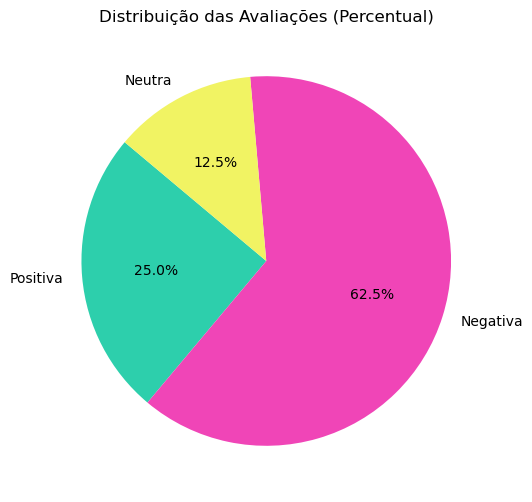

In [ ]:
# Etapa 5: Visualização das avaliações

# Criamos um gráfico simples para observar a distribuição de avaliações:
# - Positiva  
# - Negativa  
# - Neutra

import matplotlib.pyplot as plt

# Dados para o gráfico
labels = ['Positiva', 'Negativa', 'Neutra']
counts = [pos_count, neg_count, neu_count]
colors = ["#2DCFAC", "#F045B7", "#F1F363"]

# Gráfico de barras
plt.figure(figsize=(6,4))
plt.bar(labels, counts, color=colors)
plt.title("Distribuição das Avaliações das Resenhas")
plt.ylabel("Quantidade")
plt.show()

# Gráfico de pizza
plt.figure(figsize=(6,6))
plt.pie(counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title("Distribuição das Avaliações (Percentual)")
plt.show()

